# Battery LSTM Validation — 4S INR21700-50E

## Goal
8월 27일 이후 Daly BMS 로그로 1C 방전과 약 2A 충전에서 셀 표면온도 temp2_c를 60초 앞서 예측한다.

- invert-current 설정 오류는 팩 전압 상승/하강으로 자동 보정한다.
- physical_current_a는 +방전, -충전으로 통일한다.
- BMS가 보고하는 SOC는 사용하지 않는다.
- INR21700-50E의 방전전압 범위와 BC12 HPPC OCV-SOC 표로 voltage_soc_pct를 만든다.
- voltage_soc_pct를 초기값으로 삼고 4.9 Ah 기준 전류 적산을 수행한 뒤, 전압 SOC를 20% 비중으로 완만하게 결합한다.
- 표면온도는 측정 레이블이고 코어온도는 레이블이 아니다.

## Section 1: Imports and configuration

In [1]:
from pathlib import Path
import re, random, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
PROJECT_DIR=Path(r"C:\Users\YechanLee\Claude\Projects\인종설경")
OUT_DIR=Path(r"C:\jupyter\notebook\ml_validation\output\battery_lstm"); OUT_DIR.mkdir(parents=True,exist_ok=True)
FILES=sorted([p for p in PROJECT_DIR.glob("daly_log_*.csv") if p.stem.split("_")[2] >= "20260827"])
LOOKBACK=60; HORIZON=12; STRIDE_S=5; MIN_SEGMENT_S=300
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print(f"{len(FILES)} files | device={DEVICE} | output={OUT_DIR}")

12 files | device=cpu | output=C:\jupyter\notebook\ml_validation\output\battery_lstm


## Section 2: Load logs and normalize current direction

전류 부호는 옵션 기록이 아니라 전압 추세로 확인한다. 전압 하강은 방전, 상승은 충전이다.

In [2]:
OCV_SOC=np.array([[2.8467,0],[3.2325,10],[3.4453,20],[3.5466,30],[3.6381,40],
                  [3.7158,50],[3.8129,60],[3.9132,70],[4.0157,80],[4.0837,90],[4.1842,100]])
def num(s): return pd.to_numeric(s,errors="coerce")
def voltage_soc(v): return np.interp(v,OCV_SOC[:,0],OCV_SOC[:,1],left=0,right=100)
def load_one(path):
    d=pd.read_csv(path,encoding="utf-8-sig"); d["file"]=path.name
    for c in ["elapsed_s","pack_v","current_a","bms_soc","temp1_c","temp2_c","cell_delta_mv"]:
        if c in d: d[c]=num(d[c])
    cells=[c for c in d.columns if re.fullmatch(r"cell\d+_v",c)]
    for c in cells: d[c]=num(d[c])
    d["avg_cell_v"]=d[cells].mean(axis=1) if cells else d["pack_v"]/4
    d["avg_cell_v"]=d["avg_cell_v"].fillna(d["pack_v"]/4)
    d["voltage_soc_pct"]=voltage_soc(d["avg_cell_v"].to_numpy())
    a=d[d.current_a.abs()>.05]
    if len(a)<10:
        d["sign_factor"]=np.nan; d["physical_current_a"]=np.nan; d["hybrid_soc_pct"]=np.nan; d["protocol"]="idle_or_too_short"
        return d,{"file":path.name,"protocol":"idle_or_too_short","factor":np.nan,"active_rows":len(a)}
    n=max(3,len(a)//10); v0=a.pack_v.iloc[:n].median(); v1=a.pack_v.iloc[-n:].median(); raw=a.current_a.median()
    protocol="discharge" if v1<v0-.05 else "charge" if v1>v0+.05 else "ambiguous"
    expected=1.0 if protocol=="discharge" else -1.0 if protocol=="charge" else np.sign(raw)
    factor=expected/np.sign(raw) if raw else np.nan
    d["sign_factor"]=factor; d["physical_current_a"]=d.current_a*factor; d["protocol"]=protocol
    # 4S1P pack: series connection keeps the cell capacity at about 4.9 Ah.
    # + current is discharge, so Coulomb counting decreases SOC.
    aa=d.loc[a.index].copy(); dt=aa.elapsed_s.diff().fillna(0).clip(lower=0,upper=10)
    cc=voltage_soc(aa.avg_cell_v.iloc[0]) - (aa.physical_current_a*dt).cumsum()/(4.9*3600)*100
    d["hybrid_soc_pct"]=d["voltage_soc_pct"]
    d.loc[aa.index,"hybrid_soc_pct"]=(0.8*cc.to_numpy()+0.2*aa.voltage_soc_pct.to_numpy()).clip(0,100)
    return d,{"file":path.name,"protocol":protocol,"factor":factor,"v_start":v0,"v_end":v1,
              "raw_I_mean":a.current_a.mean(),"physical_I_mean":(a.current_a*factor).mean(),
              "active_rows":len(a),"active_duration_s":a.elapsed_s.iloc[-1]-a.elapsed_s.iloc[0]}
frames=[]; audit=[]
for p in FILES:
    d,i=load_one(p); frames.append(d); audit.append(i)
audit_df=pd.DataFrame(audit).sort_values("file")
display(audit_df.round(3)); audit_df.to_csv(OUT_DIR/"protocol_sign_audit.csv",index=False,encoding="utf-8-sig")

,file,protocol,factor,v_start,v_end,raw_I_mean,physical_I_mean,active_rows,active_duration_s
0,daly_log_20260827_142449.csv,discharge,1.0,15.4,11.3,4.894,4.894,3081,3967.04
1,daly_log_20260827_153903.csv,charge,1.0,11.9,12.0,-2.300,-2.300,10,9.02
2,daly_log_20260827_153927.csv,charge,1.0,13.4,16.1,-1.973,-1.973,7255,7256.98
3,daly_log_20260827_181456.csv,idle_or_too_short,NaN,NaN,NaN,NaN,NaN,0,NaN
4,daly_log_20260827_191847.csv,discharge,1.0,15.7,11.5,4.898,4.898,3564,3610.01
5,daly_log_20260827_204252.csv,charge,1.0,12.7,14.3,-2.250,-2.250,1847,1846.01
6,daly_log_20260828_165135.csv,idle_or_too_short,NaN,NaN,NaN,NaN,NaN,0,NaN
7,daly_log_20260828_170236.csv,discharge,1.0,15.4,11.3,4.898,4.898,3128,3342.98
8,daly_log_20260828_190735.csv,charge,-1.0,13.5,16.1,1.979,-1.979,7174,7177.97
9,daly_log_20260829_165601.csv,discharge,-1.0,15.5,11.4,-4.900,4.900,3235,4185.02


## Section 3: EDA and quality check

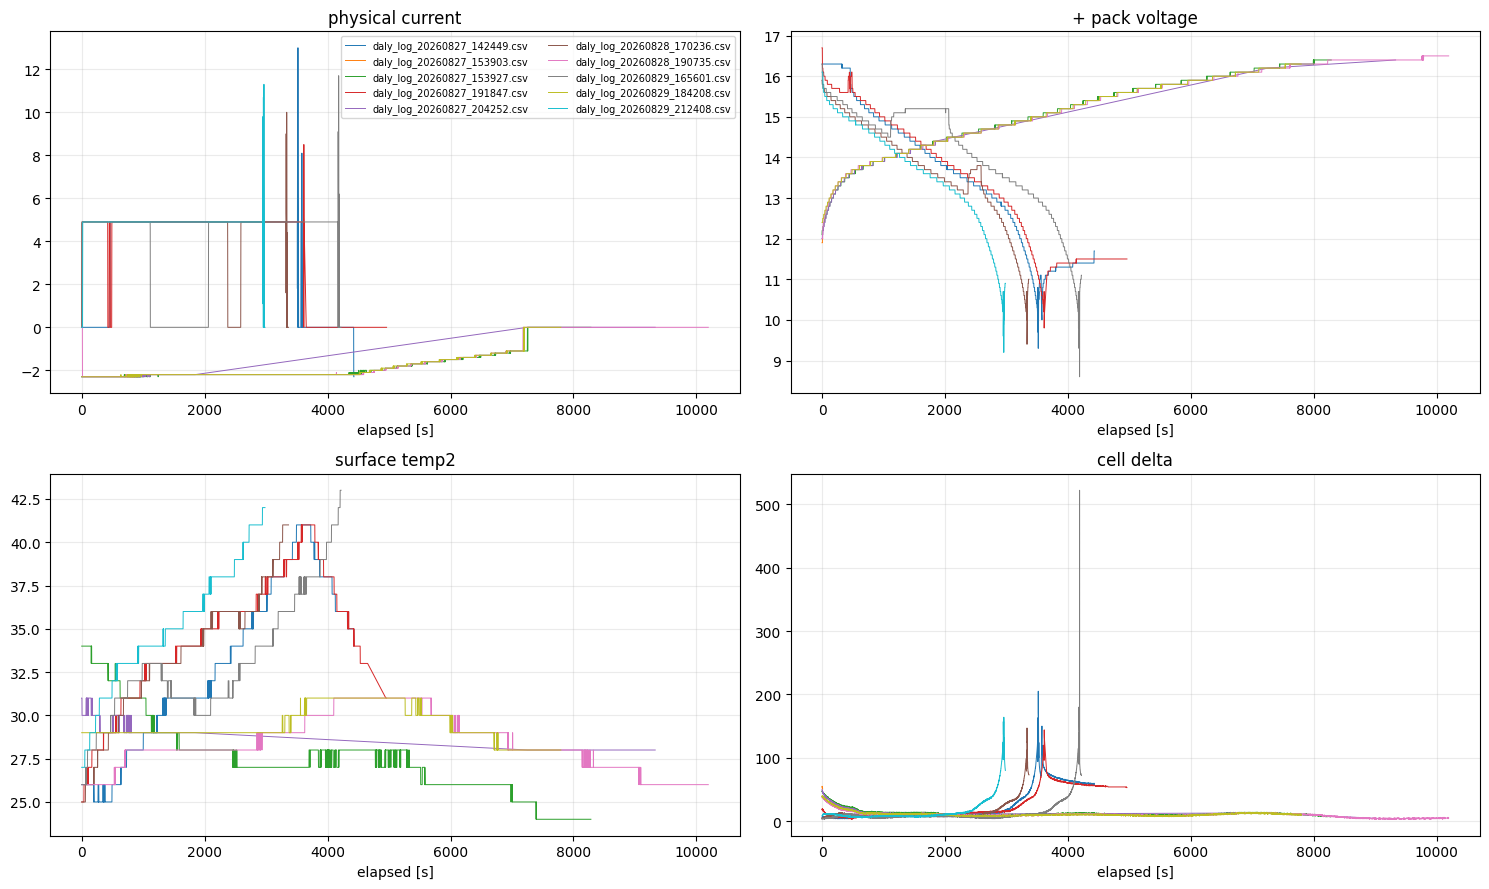

,file,protocol,rows,gaps_gt_3s,temp2_missing,temp2_min,temp2_max,cell_delta_max_mV
0,daly_log_20260827_142449.csv,discharge,4428,4,0,25,41,205.0
1,daly_log_20260827_153903.csv,charge,10,0,0,34,34,55.0
2,daly_log_20260827_153927.csv,charge,8284,11,0,24,34,48.0
3,daly_log_20260827_181456.csv,idle_or_too_short,3726,8,0,24,25,20.0
4,daly_log_20260827_191847.csv,discharge,4829,12,0,25,41,144.0
5,daly_log_20260827_204252.csv,charge,2163,2,0,28,31,50.0
6,daly_log_20260828_165135.csv,idle_or_too_short,71,0,0,25,25,3.0
7,daly_log_20260828_170236.csv,discharge,3366,0,0,25,41,147.0
8,daly_log_20260828_190735.csv,charge,10194,23,0,26,31,39.0
9,daly_log_20260829_165601.csv,discharge,4220,23,0,26,43,522.0


In [3]:
fig,ax=plt.subplots(2,2,figsize=(15,9))
for d,i in zip(frames,audit):
    if i["protocol"]=="idle_or_too_short": continue
    ax[0,0].plot(d.elapsed_s,d.physical_current_a,lw=.7,label=i["file"])
    ax[0,1].plot(d.elapsed_s,d.pack_v,lw=.7,label=i["file"])
    ax[1,0].plot(d.elapsed_s,d.temp2_c,lw=.7,label=i["file"])
    ax[1,1].plot(d.elapsed_s,d.cell_delta_mv,lw=.7,label=i["file"])
for a,t in zip(ax.ravel(),["physical current","+ pack voltage","surface temp2","cell delta"]):
    a.set_title(t); a.grid(alpha=.25); a.set_xlabel("elapsed [s]")
ax[0,0].legend(fontsize=7,ncol=2); plt.tight_layout(); plt.savefig(OUT_DIR/"01_protocol_eda.png",dpi=160); plt.show()
quality=[]
for d,i in zip(frames,audit):
    quality.append({"file":i["file"],"protocol":i["protocol"],"rows":len(d),
        "gaps_gt_3s":int(d.elapsed_s.diff().gt(3).sum()),"temp2_missing":int(d.temp2_c.isna().sum()),
        "temp2_min":d.temp2_c.min(),"temp2_max":d.temp2_c.max(),"cell_delta_max_mV":d.cell_delta_mv.max()})
quality_df=pd.DataFrame(quality).sort_values("file"); display(quality_df.round(2))

## Section 4: Sequence construction

행을 무작위로 분할하지 않고 파일 단위로 분리한다. 8월 27~28일을 학습, 8월 29일을 독립 테스트로 사용한다. BMS SOC는 제외하고 전압 SOC와 전류 적산을 결합한 hybrid_soc_pct를 feature로 사용한다.

In [4]:
FEATURES=["physical_current_a","pack_v","avg_cell_v","cell_delta_mv","temp1_c","temp2_c","hybrid_soc_pct"]
TARGET="temp2_c"
def make_segments(d):
    d=d.copy(); active=d.physical_current_a.abs().gt(.05)
    d["seg"]=(d.elapsed_s.diff().gt(3) | active.ne(active.shift())).cumsum(); out=[]
    for _,s in d.groupby("seg"):
        if s.elapsed_s.iloc[-1]-s.elapsed_s.iloc[0] < MIN_SEGMENT_S: continue
        if s.physical_current_a.abs().gt(.05).sum()<10: continue
        s=s.iloc[::STRIDE_S].reset_index(drop=True)
        s[FEATURES]=s[FEATURES].apply(num).interpolate(limit=2).ffill().bfill()
        if len(s)>LOOKBACK+HORIZON: out.append(s)
    return out
segments=[]
for d,i in zip(frames,audit):
    if i["protocol"]=="idle_or_too_short": continue
    for s in make_segments(d):
        s["split"]="test" if i["file"].startswith("daly_log_20260829") else "train"
        s["protocol"]=i["protocol"]; s["file"]=i["file"]; segments.append(s)
tr=[s for s in segments if s.split.iloc[0]=="train"]; te=[s for s in segments if s.split.iloc[0]=="test"]
def build(ss,sx=None,sy=None,fit=False):
    if fit:
        bx=pd.concat([s[FEATURES] for s in ss])
        by=pd.concat([s[[TARGET]] for s in ss])
        sx=StandardScaler().fit(bx); sy=StandardScaler().fit(by)
    X=[]; y=[]; meta=[]
    for s in ss:
        xx=sx.transform(s[FEATURES]); yy=sy.transform(s[[TARGET]]).ravel()
        for j in range(LOOKBACK,len(s)-HORIZON+1):
            X.append(xx[j-LOOKBACK:j]); y.append(yy[j+HORIZON-1])
            meta.append((s.file.iloc[0],s.protocol.iloc[0],float(s.elapsed_s.iloc[j+HORIZON-1])))
    return np.asarray(X,np.float32),np.asarray(y,np.float32),meta,sx,sy
Xtr,ytr,mtr,sx,sy=build(tr,fit=True); Xte,yte,mte,_,_=build(te,sx,sy)
print("train",Xtr.shape,"test",Xte.shape); print("test files",sorted(set(x[0] for x in mte)))

train (3706, 60, 7) test (2129, 60, 7)
test files ['daly_log_20260829_165601.csv', 'daly_log_20260829_184208.csv', 'daly_log_20260829_212408.csv']


## Section 5: LSTM training

In [5]:
class TempLSTM(nn.Module):
    def __init__(self,nf,hidden=48,layers=2):
        super().__init__()
        self.lstm=nn.LSTM(nf,hidden,layers,batch_first=True,dropout=.15)
        self.head=nn.Sequential(nn.Linear(hidden,24),nn.ReLU(),nn.Linear(24,1))
    def forward(self,x): return self.head(self.lstm(x)[0][:,-1]).squeeze(-1)
model=TempLSTM(len(FEATURES)).to(DEVICE)
opt=torch.optim.Adam(model.parameters(),lr=2e-3,weight_decay=1e-5); loss_fn=nn.MSELoss()
loader=DataLoader(TensorDataset(torch.tensor(Xtr),torch.tensor(ytr)),batch_size=512,shuffle=True)
Xte_t=torch.tensor(Xte,device=DEVICE); yte_t=torch.tensor(yte,device=DEVICE)
hist=[]; best=(float("inf"),None)
for ep in range(1,16):
    model.train(); ls=[]
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad()
        loss=loss_fn(model(xb),yb); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1); opt.step(); ls.append(loss.item())
    model.eval()
    with torch.no_grad(): vl=loss_fn(model(Xte_t),yte_t).item()
    hist.append([ep,float(np.mean(ls)),vl])
    if vl<best[0]: best=(vl,{k:v.detach().cpu().clone() for k,v in model.state_dict().items()})
    if ep==1 or ep%5==0: print(f"epoch {ep:3d} train_mse={np.mean(ls):.4f} test_mse={vl:.4f}")
model.load_state_dict(best[1])
torch.save({"state_dict":model.state_dict(),"features":FEATURES,"lookback":LOOKBACK,"horizon":HORIZON},OUT_DIR/"battery_temp_lstm.pt")
history=pd.DataFrame(hist,columns=["epoch","train_mse","test_mse"]); history.to_csv(OUT_DIR/"training_history.csv",index=False)

epoch   1 train_mse=0.9742 test_mse=1.1504


epoch   5 train_mse=0.0545 test_mse=0.0669


epoch  10 train_mse=0.0114 test_mse=0.0183


epoch  15 train_mse=0.0102 test_mse=0.0152


## Section 6: Baseline, metrics, and visualization

,model,MAE_C,RMSE_C,R2,n
0,Persistence,0.1775,0.4214,0.9864,2129
1,LSTM,0.2668,0.4131,0.9869,2129


,file,protocol,n,LSTM_MAE_C,LSTM_RMSE_C,Persistence_MAE_C
0,daly_log_20260829_165601.csv,discharge,416,0.4120,0.4883,0.3774
1,daly_log_20260829_184208.csv,charge,1196,0.1442,0.2711,0.0819
2,daly_log_20260829_212408.csv,discharge,517,0.4336,0.5840,0.2379


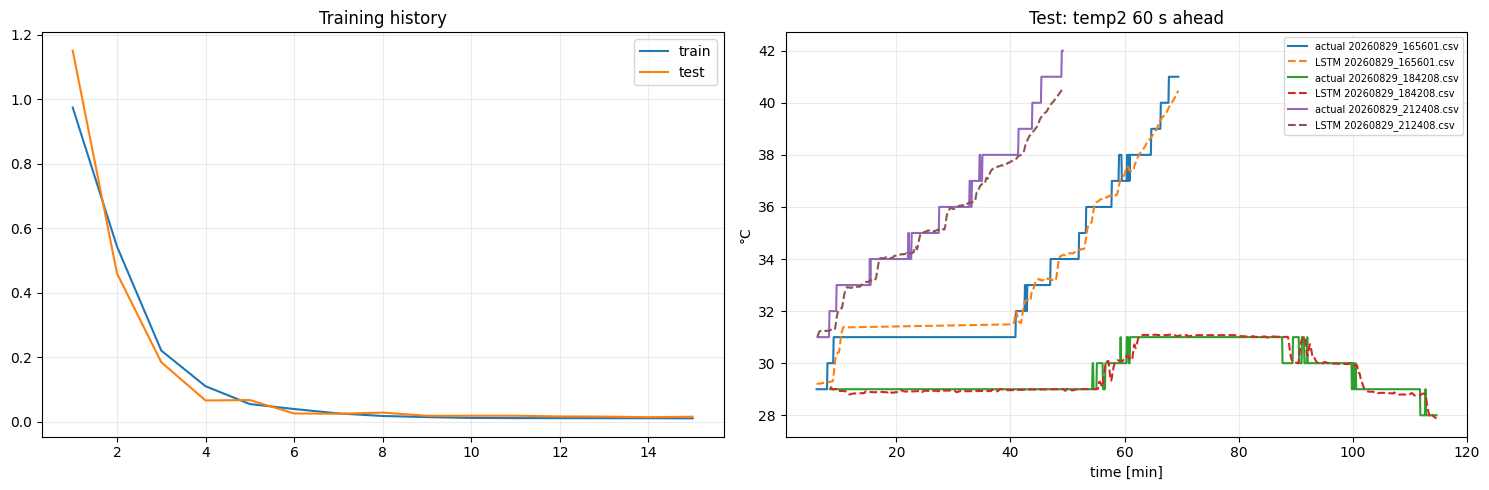

In [6]:
model.eval()
with torch.no_grad(): psc=model(Xte_t).cpu().numpy()
pred=sy.inverse_transform(psc[:,None]).ravel()
actual=sy.inverse_transform(yte[:,None]).ravel()
last=sy.inverse_transform(Xte[:,-1,FEATURES.index("temp2_c")][:,None]).ravel()
def metric(name,y,p): return {"model":name,"MAE_C":mean_absolute_error(y,p),"RMSE_C":mean_squared_error(y,p)**.5,"R2":r2_score(y,p),"n":len(y)}
metrics_df=pd.DataFrame([metric("Persistence",actual,last),metric("LSTM",actual,pred)])
display(metrics_df.round(4)); metrics_df.to_csv(OUT_DIR/"metrics_overall.csv",index=False,encoding="utf-8-sig")
pred_df=pd.DataFrame([{"file":mte[i][0],"protocol":mte[i][1],"time_s":mte[i][2],"actual_temp2_c":actual[i],"lstm_temp2_c":pred[i],"persistence_temp2_c":last[i]} for i in range(len(mte))])
per=[]
for (f,p),g in pred_df.groupby(["file","protocol"]):
    per.append({"file":f,"protocol":p,"n":len(g),"LSTM_MAE_C":mean_absolute_error(g.actual_temp2_c,g.lstm_temp2_c),"LSTM_RMSE_C":mean_squared_error(g.actual_temp2_c,g.lstm_temp2_c)**.5,"Persistence_MAE_C":mean_absolute_error(g.actual_temp2_c,g.persistence_temp2_c)})
per_df=pd.DataFrame(per); display(per_df.round(4))
pred_df.to_csv(OUT_DIR/"test_predictions.csv",index=False,encoding="utf-8-sig"); per_df.to_csv(OUT_DIR/"metrics_per_file.csv",index=False,encoding="utf-8-sig")
fig,ax=plt.subplots(1,2,figsize=(15,5))
ax[0].plot(history.epoch,history.train_mse,label="train"); ax[0].plot(history.epoch,history.test_mse,label="test"); ax[0].set_title("Training history"); ax[0].legend(); ax[0].grid(alpha=.25)
for (f,p),g in pred_df.groupby(["file","protocol"]):
    g=g.sort_values("time_s"); ax[1].plot(g.time_s/60,g.actual_temp2_c,label="actual "+f[-19:]); ax[1].plot(g.time_s/60,g.lstm_temp2_c,"--",label="LSTM "+f[-19:])
ax[1].set_title("Test: temp2 60 s ahead"); ax[1].set_xlabel("time [min]"); ax[1].set_ylabel("°C"); ax[1].legend(fontsize=7); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.savefig(OUT_DIR/"02_lstm_evaluation.png",dpi=160); plt.show()

## Section 7: Interpretation and limitations

- bms_soc는 모델 입력에서 제외했다. 초기 SOC는 HPPC OCV-SOC로 정하고, 이후 전류 적산을 80%, 전압 SOC를 20%로 결합한다.
- Samsung INR21700-50E 데이터시트는 1C = 4,900mA와 2.50V 종지 시험을 뒷받침하지만 정밀 OCV-SOC 표는 제공하지 않으므로 현재 셀의 BC12 HPPC 휴지전압을 사용한다.
- 4.9 Ah는 INR21700-50E 정격용량 가정이며, 실제 셀 열화·온도·충방전 효율에 따라 오차가 생긴다. 실제 용량시험 후 이 값을 교체해야 한다.
- 부하 중 전압은 OCV보다 낮아질 수 있어 voltage_soc_pct는 보정용이고, hybrid_soc_pct도 절대 SOC 인증값이 아니다.
- 출력 레이블은 표면온도이며 코어온도 정답이 아니다.
- 보호회로로 방전이 중간 종료돼도 파일을 버리지 않고 0A 이후를 segment로 분리한다. 5분 미만 구간만 제외한다.